In [ ]:
### Initial ####
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw.csv")

print(df.head())

df.info()

print(df.describe())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   i

In [5]:
#### Converted Date########
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


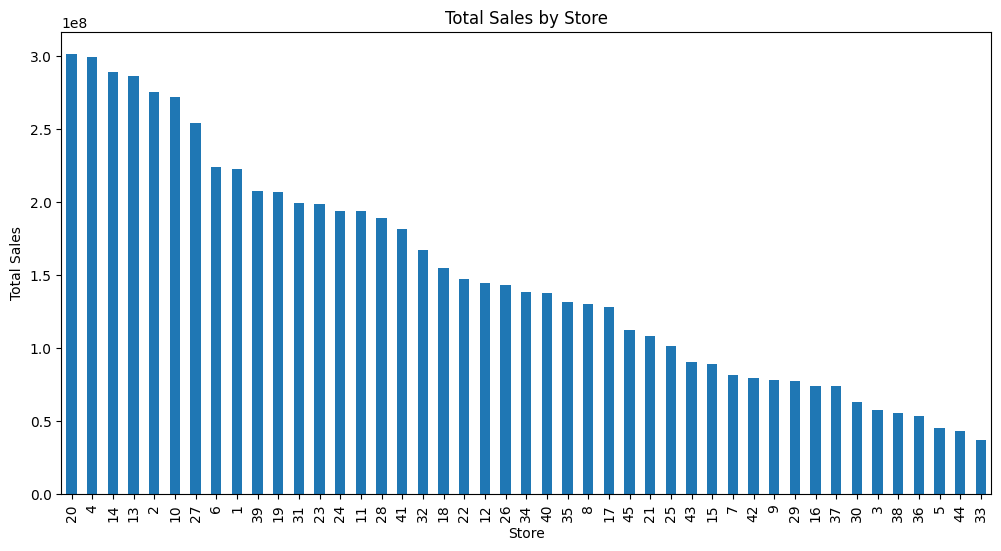

In [6]:
####### Checked Which Stores sell the most#############
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
)

store_sales

plt.figure(figsize=(12,6))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

#Store 20 has highest sales
#Store 33 has lowest sales
#Large difference between stores

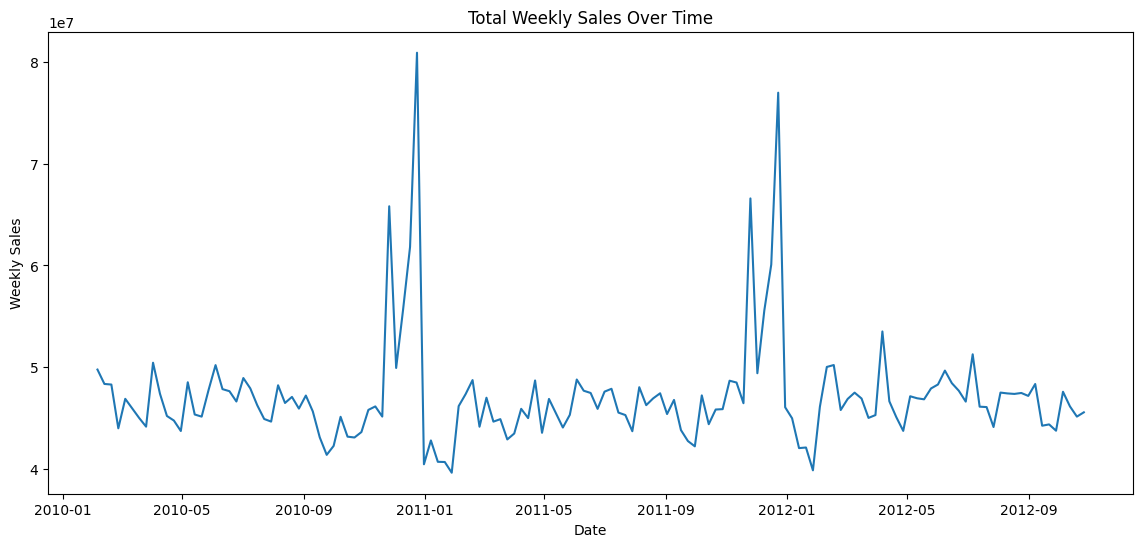

In [7]:
########## Checked Sales Trend ###############
sales_over_time = (
    df.groupby("Date")["Weekly_Sales"]
      .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    sales_over_time.index,
    sales_over_time.values
)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

#Trend is consistent, however holidays spike 

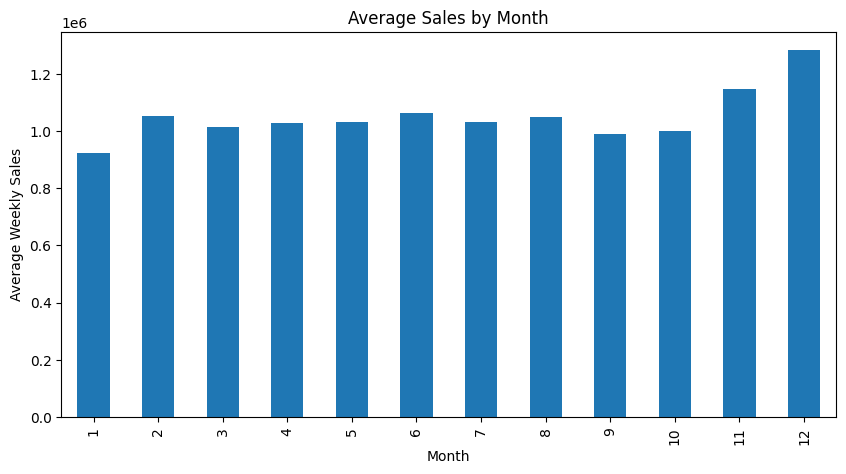

In [8]:
########## Checked Seasonality ###############
df["Month"] = df["Date"].dt.month #Created Month Column

monthly_sales = (
    df.groupby("Month")["Weekly_Sales"]
      .mean()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.show()

#December stands out with highest sales
#January has lowest

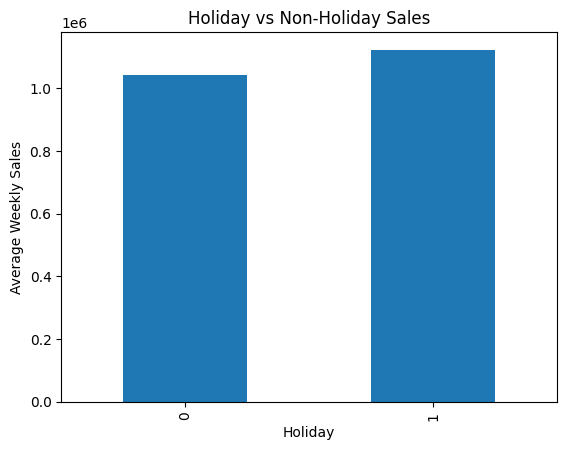

In [9]:
###### Holiday versus non holiday #########
holiday_sales = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
      .mean()
)

holiday_sales

holiday_sales.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")

plt.show()

#Holiday sales increas by about 100,000

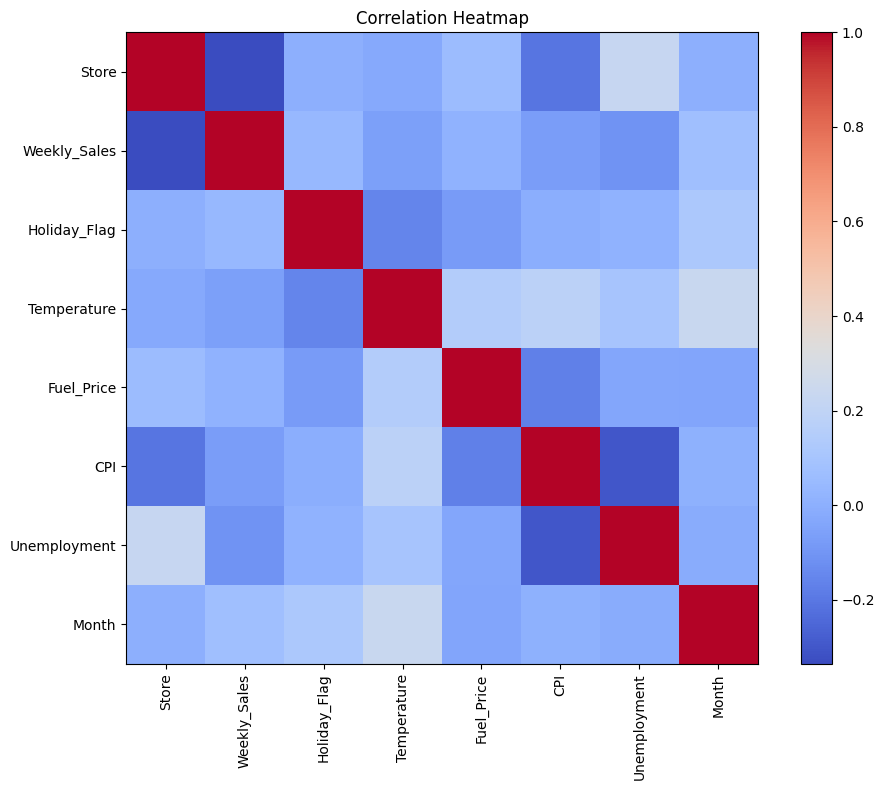

In [10]:
########## Correlation Heatmap ##############
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

#Weekly sales and holiday status or month appear to be useful predictors

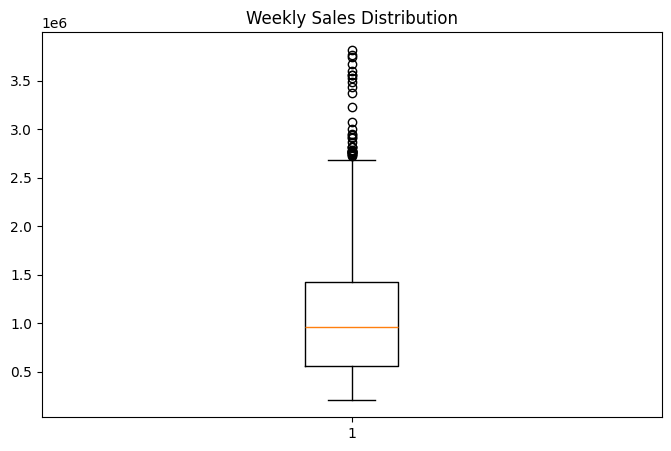

In [11]:
#########Outlier Check################
plt.figure(figsize=(8,5))

plt.boxplot(df["Weekly_Sales"])

plt.title("Weekly Sales Distribution")

plt.show()

#Extreme values likely valid seasonal spikes not errors